<a href="https://colab.research.google.com/github/rounak393/clab/blob/main/test1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_c03d989b55c966d18c971a92b023645b"

!kaggle datasets download -d britikak/busi-dataset



Dataset URL: https://www.kaggle.com/datasets/britikak/busi-dataset
License(s): unknown
100% 195M/195M [00:02<00:00, 99.4MB/s]



In [2]:
!unzip -q busi-dataset.zip -d busi_dataset

In [14]:
import os
import copy
import torch
import random
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import albumentations as A
from tqdm import tqdm

# Update this if your folder name is different
BASE_DIR = "/content/busi_dataset/Dataset_BUSI_with_GT"
CLASSES = ["benign", "malignant"]

IMG_SIZE = 256
BATCH_SIZE = 8
SEED = 42
EPOCHS = 100

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [15]:
class BUSISegmentationDataset(Dataset):
    def __init__(self, base_dir, classes, transform=None):
        self.samples = []
        self.transform = transform

        for cls in classes:
            cls_dir = os.path.join(base_dir, cls)
            images = [f for f in os.listdir(cls_dir) if f.endswith(".png") and "_mask" not in f]

            for img_name in images:
                img_path = os.path.join(cls_dir, img_name)
                base_name = img_name.replace(".png", "")

                mask_files = [
                    f for f in os.listdir(cls_dir)
                    if f.startswith(base_name + "_mask") and f.endswith(".png")
                ]

                if len(mask_files) == 0:
                    continue

                mask_paths = [os.path.join(cls_dir, f) for f in mask_files]
                self.samples.append((img_path, mask_paths))

        assert len(self.samples) > 0, "No valid image-mask pairs found!"

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_paths = self.samples[idx]

        image = np.array(Image.open(img_path).convert("RGB"))
        combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)

        for mpath in mask_paths:
            mask = np.array(Image.open(mpath).convert("L"))
            mask = (mask > 0).astype(np.uint8)
            combined_mask = np.logical_or(combined_mask, mask)

        combined_mask = combined_mask.astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=combined_mask)
            image = augmented["image"]
            combined_mask = augmented["mask"]

        combined_mask = (combined_mask > 0.5).astype(np.float32)

        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(combined_mask).unsqueeze(0).float()

        return image, mask

In [16]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0)
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0)
])

full_dataset = BUSISegmentationDataset(BASE_DIR, classes=CLASSES, transform=None)

total_size = len(full_dataset)
indices = list(range(total_size))

np.random.seed(SEED)
np.random.shuffle(indices)

train_size = int(0.8 * total_size)
val_size   = int(0.1 * total_size)

val_indices = indices[:val_size]
train_indices   = indices[val_size:train_size + val_size]

train_dataset = Subset(
    BUSISegmentationDataset(BASE_DIR, CLASSES, transform=train_transform), train_indices
)
val_dataset = Subset(
    BUSISegmentationDataset(BASE_DIR, CLASSES, transform=val_transform), val_indices
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [17]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.att1 = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.conv1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.att2 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.conv2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.att3 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.conv3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att4 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.conv4 = DoubleConv(128, 64)

        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        g1 = self.up1(x5)
        x4_att = self.att1(g=g1, x=x4)
        d1 = self.conv1(torch.cat([x4_att, g1], dim=1))

        g2 = self.up2(d1)
        x3_att = self.att2(g=g2, x=x3)
        d2 = self.conv2(torch.cat([x3_att, g2], dim=1))

        g3 = self.up3(d2)
        x2_att = self.att3(g=g3, x=x2)
        d3 = self.conv3(torch.cat([x2_att, g3], dim=1))

        g4 = self.up4(d3)
        x1_att = self.att4(g=g4, x=x1)
        d4 = self.conv4(torch.cat([x1_att, g4], dim=1))

        return self.outc(d4)

In [18]:
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        preds = torch.sigmoid(logits)
        preds_f = preds.view(-1)
        targets_f = targets.view(-1)
        inter = (preds_f * targets_f).sum()
        dice_loss = 1 - (2 * inter + self.smooth) / (preds_f.sum() + targets_f.sum() + self.smooth)
        return 0.5 * bce_loss + 0.5 * dice_loss

def dice_coef(y_true, y_pred, smooth=1e-5):
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    inter = (y_true_f * y_pred_f).sum()
    return (2. * inter + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)

def iou_score(preds, masks, threshold=0.5, eps=1e-6):
    preds_bin = (preds > threshold).float()
    masks_bin = (masks > threshold).float()
    inter = (preds_bin * masks_bin).sum().item()
    union = preds_bin.sum().item() + masks_bin.sum().item() - inter
    return inter / (union + eps)

Using device: cuda

Starting training for 10 epochs...



Epoch 1/10 [Val]: 100%|██████████| 8/8 [00:01<00:00,  4.81it/s]



Epoch 1/10
Train Loss: 0.6589 | Val Loss: 0.6184
Train Dice: 0.1777 | Val Dice: 0.2133
Train IoU : 0.1246  | Val IoU : 0.2367
✓ Best model saved (Val Loss: 0.6184)


Epoch 2/10 [Val]: 100%|██████████| 8/8 [00:01<00:00,  4.85it/s]



Epoch 2/10
Train Loss: 0.5645 | Val Loss: 1.1670
Train Dice: 0.2564 | Val Dice: 0.2021
Train IoU : 0.3162  | Val IoU : 0.1238


...


Epoch 8/10
Train Loss: 0.4000 | Val Loss: 0.4203
Train Dice: 0.4309 | Val Dice: 0.3853
Train IoU : 0.4693  | Val IoU : 0.4049
✓ Best model saved (Val Loss: 0.4203)


Epoch 9/10 [Val]: 100%|██████████| 8/8 [00:01<00:00,  4.83it/s]



Epoch 9/10
Train Loss: 0.3803 | Val Loss: 0.4164
Train Dice: 0.4539 | Val Dice: 0.3843
Train IoU : 0.4892  | Val IoU : 0.3784
✓ Best model saved (Val Loss: 0.4164)


Epoch 10/10 [Val]: 100%|██████████| 8/8 [00:01<00:00,  4.86it/s]



Epoch 10/10
Train Loss: 0.3681 | Val Loss: 0.3922
Train Dice: 0.4708 | Val Dice: 0.4015
Train IoU : 0.4949  | Val IoU : 0.4405
✓ Best model saved (Val Loss: 0.3922)

Training Complete! Best Validation Loss: 0.3922



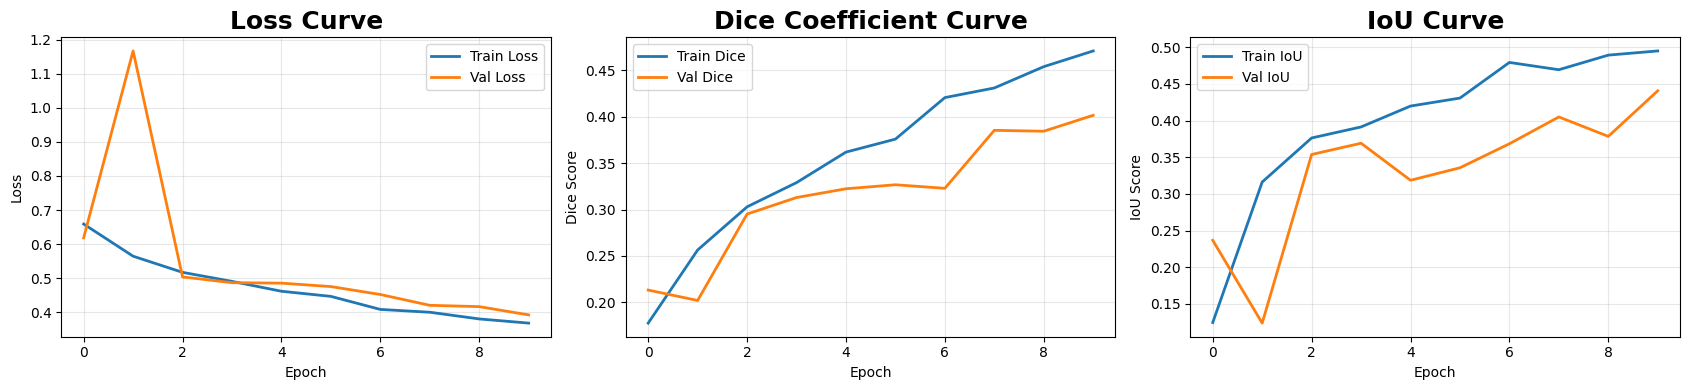

In [21]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


model = AttentionUNet(n_channels=3, n_classes=1).to(device)

# Initialize Loss, Optimizer, and Learning Rate Scheduler
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

EPOCHS = 10

train_losses, val_losses = [], []
train_dice_scores, val_dice_scores = [], []
train_iou_scores, val_iou_scores = [], []

best_val_loss = float("inf")
best_model_weights = None

print(f"\nStarting training for {EPOCHS} epochs...\n")


for epoch in range(EPOCHS):

    model.train()
    train_loss = train_dice = train_iou = 0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images, masks = images.to(device), masks.to(device)

        # Forward pass
        logits = model(images)
        loss = criterion(logits, masks)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics (Apply sigmoid to raw logits)
        preds_prob = torch.sigmoid(logits)
        train_loss += loss.item()
        train_dice += dice_coef(masks, preds_prob).item()
        train_iou += iou_score(preds_prob, masks)

    #  VALIDATION PHASE
    model.eval()
    val_loss = val_dice = val_iou = 0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            logits = model(images)
            loss = criterion(logits, masks)

            # Metrics
            preds_prob = torch.sigmoid(logits)
            val_loss += loss.item()
            val_dice += dice_coef(masks, preds_prob).item()
            val_iou += iou_score(preds_prob, masks)


    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss / len(val_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_dice   = val_dice / len(val_loader)
    avg_train_iou  = train_iou / len(train_loader)
    avg_val_iou    = val_iou / len(val_loader)


    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_dice_scores.append(avg_train_dice)
    val_dice_scores.append(avg_val_dice)
    train_iou_scores.append(avg_train_iou)
    val_iou_scores.append(avg_val_iou)

    #  save best model
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Train Dice: {avg_train_dice:.4f} | Val Dice: {avg_val_dice:.4f}")
    print(f"Train IoU : {avg_train_iou:.4f}  | Val IoU : {avg_val_iou:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_attention_unet.pth")
        print(f"✓ Best model saved (Val Loss: {best_val_loss:.4f})")

    # Update learning rate if validation loss stops improving
    scheduler.step(avg_val_loss)

print("\n" + "="*50)
print(f"Training Complete! Best Validation Loss: {best_val_loss:.4f}")
print("="*50 + "\n")

# Load the best weights back into the model before finishing
model.load_state_dict(best_model_weights)


plt.figure(figsize=(17, 4))

# Loss Plot
plt.subplot(1, 3, 1)
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Val Loss", linewidth=2)
plt.title("Loss Curve", fontsize=18, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Dice Plot
plt.subplot(1, 3, 2)
plt.plot(train_dice_scores, label="Train Dice", linewidth=2)
plt.plot(val_dice_scores, label="Val Dice", linewidth=2)
plt.title("Dice Coefficient Curve", fontsize=18, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True, alpha=0.3)

# iou plt
plt.subplot(1, 3, 3)
plt.plot(train_iou_scores, label="Train IoU", linewidth=2)
plt.plot(val_iou_scores, label="Val IoU", linewidth=2)
plt.title("IoU Curve", fontsize=18, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("IoU Score")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300, bbox_inches='tight')
plt.show()

In [22]:

print("Evaluating Model on the Unseen Test Set...")


model.eval()
test_loss = test_dice = test_iou = 0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Evaluating [Test]"):
        images, masks = images.to(device), masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        preds_prob = torch.sigmoid(logits)
        test_loss += loss.item()
        test_dice += dice_coef(masks, preds_prob).item()
        test_iou += iou_score(preds_prob, masks)

avg_test_loss = test_loss / len(test_loader)
avg_test_dice = test_dice / len(test_loader)
avg_test_iou  = test_iou / len(test_loader)

print("\n✅ Final Test Results:")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Dice: {avg_test_dice:.4f}")
print(f"Test IoU : {avg_test_iou:.4f}")

Evaluating Model on the Unseen Test Set...


Evaluating [Test]: 100%|██████████| 9/9 [00:01<00:00,  5.34it/s]


✅ Final Test Results:
Test Loss: 0.3568
Test Dice: 0.4689
Test IoU : 0.4990
